# **Stage 5: Modeling & AI Integration**

## Step 1 — Setup, GPU Check & Data Encoding
Initialize the SentenceTransformer embedder, load the three dataset splits, and encode all emails into 384-dimensional vectors.

## Step 2 — Autoencoder Architecture & Training
Define the 384→128→64→32→64→128→384 deep autoencoder, train on normal emails only for 20 epochs, and track validation loss to confirm no overfitting.

## Step 3 — Threshold Tuning & Model Evaluation
Compute reconstruction errors on the test set, sweep across percentiles (95→50), and plot Recall vs. FPR to identify the optimal detection threshold. Save model weights.

## Step 4 — Explainable AI (xAI)
Token ablation analysis: remove one word at a time from the top anomalous emails and measure score delta to identify which words drove the anomaly signal.

In [3]:
# --- Cell 1: Setup & Data Encoding ---
import pandas as pd
import numpy as np
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sentence_transformers import SentenceTransformer

# 1. GPU Check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Device active: {device.type.upper()}")

# 2. Define standard paths (Directly in Colab)
BASE_PATH = "/content/"

# 3. Load the Transformer Model
print("Loading SentenceTransformer...")
embedder = SentenceTransformer('all-MiniLM-L6-v2', device=device)

# 4. Efficient Encoding Function
def encode_data(csv_name):
    print(f"Loading and encoding {csv_name}...")
    df = pd.read_csv(os.path.join(BASE_PATH, csv_name), dtype=str)
    sentences = df['text'].fillna("").tolist()

    # Encode with progress bar, convert to tensor, and keep on CPU RAM initially
    embeddings = embedder.encode(sentences, batch_size=256, show_progress_bar=True, convert_to_tensor=True).cpu()
    return embeddings, df

# Generate embeddings for all 3 splits
X_train_emb, _ = encode_data("train_safe.csv")
X_val_emb, _ = encode_data("val_safe.csv")
X_test_emb, df_test = encode_data("test_mixed.csv")

# Extract the true labels for the test set
y_test = df_test['label'].astype(int).values
print("✅ All data encoded successfully!")

🚀 Device active: CUDA
Loading SentenceTransformer...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading and encoding train_safe.csv...


Batches:   0%|          | 0/1445 [00:00<?, ?it/s]

Loading and encoding val_safe.csv...


Batches:   0%|          | 0/161 [00:00<?, ?it/s]

Loading and encoding test_mixed.csv...


Batches:   0%|          | 0/472 [00:00<?, ?it/s]

✅ All data encoded successfully!


In [4]:
# --- Cell 2: Architecture & Training ---

# 1. The Deep Autoencoder Architecture
class SpearPhishingAE(nn.Module):
    def __init__(self, input_dim=384):
        super(SpearPhishingAE, self).__init__()
        # Compression (Finding the fingerprint)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32) # The bottleneck
        )
        # Reconstruction
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

# 2. Initialize Model, Loss, and DataLoaders
model_ae = SpearPhishingAE().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model_ae.parameters(), lr=1e-3)

# DataLoaders for batching
train_loader = DataLoader(TensorDataset(X_train_emb), batch_size=512, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_emb), batch_size=512, shuffle=False)

# 3. Professional Training Loop
print("Starting Model Training...")
epochs = 20

for epoch in range(epochs):
    # Training Phase
    model_ae.train()
    train_loss = 0
    for batch in train_loader:
        inputs = batch[0].to(device)
        optimizer.zero_grad()
        outputs = model_ae(inputs)
        loss = criterion(outputs, inputs)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation Phase (Proving no Overfitting)
    model_ae.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            inputs = batch[0].to(device)
            outputs = model_ae(inputs)
            loss = criterion(outputs, inputs)
            val_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")

Starting Model Training...
Epoch 1/20 | Train Loss: 0.001516 | Val Loss: 0.001262
Epoch 2/20 | Train Loss: 0.001203 | Val Loss: 0.001174
Epoch 3/20 | Train Loss: 0.001154 | Val Loss: 0.001149
Epoch 4/20 | Train Loss: 0.001135 | Val Loss: 0.001134
Epoch 5/20 | Train Loss: 0.001126 | Val Loss: 0.001128
Epoch 6/20 | Train Loss: 0.001120 | Val Loss: 0.001120
Epoch 7/20 | Train Loss: 0.001113 | Val Loss: 0.001115
Epoch 8/20 | Train Loss: 0.001107 | Val Loss: 0.001109
Epoch 9/20 | Train Loss: 0.001101 | Val Loss: 0.001104
Epoch 10/20 | Train Loss: 0.001097 | Val Loss: 0.001100
Epoch 11/20 | Train Loss: 0.001092 | Val Loss: 0.001095
Epoch 12/20 | Train Loss: 0.001087 | Val Loss: 0.001090
Epoch 13/20 | Train Loss: 0.001083 | Val Loss: 0.001086
Epoch 14/20 | Train Loss: 0.001079 | Val Loss: 0.001082
Epoch 15/20 | Train Loss: 0.001075 | Val Loss: 0.001080
Epoch 16/20 | Train Loss: 0.001072 | Val Loss: 0.001076
Epoch 17/20 | Train Loss: 0.001069 | Val Loss: 0.001074
Epoch 18/20 | Train Loss: 0.00

🔍 Testing different thresholds to find the optimum sweet spot...

Top 05% Anomalous (Percentile 95) -> Caught Attacks: 22.3% | False Alarms: 2.0%
Top 10% Anomalous (Percentile 90) -> Caught Attacks: 37.3% | False Alarms: 5.2%
Top 15% Anomalous (Percentile 85) -> Caught Attacks: 47.8% | False Alarms: 9.2%
Top 20% Anomalous (Percentile 80) -> Caught Attacks: 56.1% | False Alarms: 13.7%
Top 25% Anomalous (Percentile 75) -> Caught Attacks: 62.2% | False Alarms: 18.5%
Top 30% Anomalous (Percentile 70) -> Caught Attacks: 67.2% | False Alarms: 23.5%
Top 35% Anomalous (Percentile 65) -> Caught Attacks: 71.2% | False Alarms: 28.6%
Top 40% Anomalous (Percentile 60) -> Caught Attacks: 74.6% | False Alarms: 33.9%
Top 50% Anomalous (Percentile 50) -> Caught Attacks: 81.0% | False Alarms: 44.5%


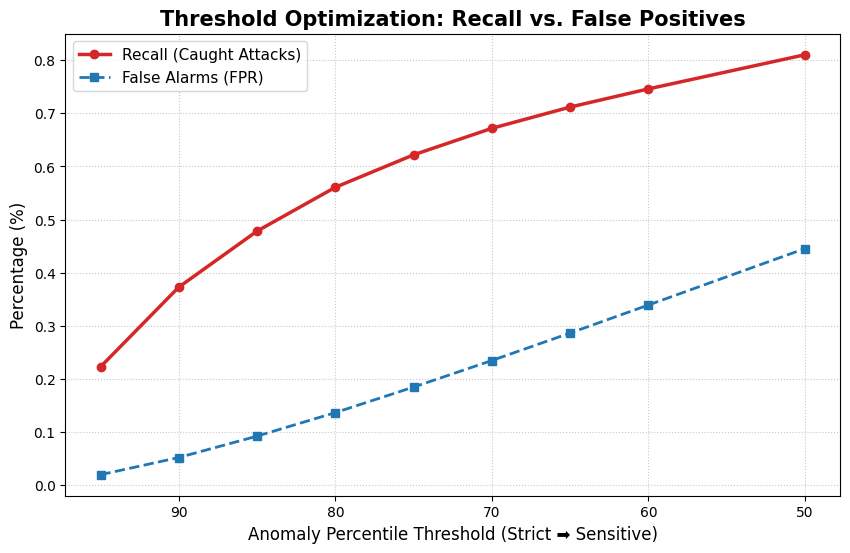

✅ Model weights saved locally to: /content/spear_phishing_ae_weights.pth


In [5]:
# --- Cell 3: Advanced Threshold Tuning (Finding the Sweet Spot) ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

# 1. Evaluate the model on the TEST set
model_ae.eval()
with torch.no_grad():
    X_test_gpu = X_test_emb.to(device)
    reconstructed = model_ae(X_test_gpu)
    mse_errors = torch.mean((X_test_gpu - reconstructed)**2, dim=1).cpu().numpy()

# 2. Test a range of percentiles
percentiles_to_test = [95, 90, 85, 80, 75, 70, 65, 60, 50]
results = []

print("🔍 Testing different thresholds to find the optimum sweet spot...\n")

for p in percentiles_to_test:
    thresh = np.percentile(mse_errors, p)
    y_pred = [1 if e > thresh else 0 for e in mse_errors]
    cm = confusion_matrix(y_test, y_pred)

    if cm.shape == (2, 2):
        tp, fn, fp, tn = cm[1, 1], cm[1, 0], cm[0, 1], cm[0, 0]
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    else:
        recall, fpr = 0, 0

    results.append({'Percentile': p, 'Recall (Detection)': recall, 'FPR (False Alarms)': fpr})
    print(f"Top {100-p:02d}% Anomalous (Percentile {p:02d}) -> Caught Attacks: {recall:.1%} | False Alarms: {fpr:.1%}")

# 3. Visualize the Trade-off Curve
df_results = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
# Plot Recall (Good)
plt.plot(df_results['Percentile'], df_results['Recall (Detection)'],
         marker='o', label='Recall (Caught Attacks)', color='#d62728', linewidth=2.5)
# Plot False Positive Rate (Bad)
plt.plot(df_results['Percentile'], df_results['FPR (False Alarms)'],
         marker='s', label='False Alarms (FPR)', color='#1f77b4', linestyle='--', linewidth=2)

plt.gca().invert_xaxis() # Reverse X axis to go from strict (95) to sensitive (50)
plt.title("Threshold Optimization: Recall vs. False Positives", fontsize=15, fontweight='bold')
plt.xlabel("Anomaly Percentile Threshold (Strict ➡️ Sensitive)", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

# 4. Save the model weights
import os
model_save_path = os.path.join(BASE_PATH, "spear_phishing_ae_weights.pth")
torch.save(model_ae.state_dict(), model_save_path)
print(f"✅ Model weights saved locally to: {model_save_path}")

In [6]:
# --- Cell 4: Explainable AI (xAI) - Analyzing the Most Anomalous Emails ---
import pandas as pd

# 1. Ensure mse_errors exist in memory (from Cell 3)
if 'mse_errors' not in locals():
    print("Error: mse_errors not found. Please run Cell 3 first.")
else:
    # 2. Add the anomaly scores back to the test dataframe
    df_test['anomaly_score'] = mse_errors

    # 3. Sort by the highest error (The most anomalous/weirdest emails)
    top_anomalies = df_test.sort_values(by='anomaly_score', ascending=False).head(5)

    print("="*60)
    print(" 🚨 xAI: TOP 5 MOST ANOMALOUS EMAILS DETECTED")
    print(" (These emails completely violated the 'Normal' Enron Fingerprint)")
    print("="*60)

    for i, row in top_anomalies.iterrows():
        print(f"\n🔴 Anomaly Score (MSE): {row['anomaly_score']:.6f}")
        print(f"Label: {'Phishing (1)' if row['label'] == '1' else 'Safe (0)'}")
        # Print the first 250 characters of the text to see what triggered it
        print(f"Content: {str(row['text'])[:250]}...")
        print("-" * 60)

 🚨 xAI: TOP 5 MOST ANOMALOUS EMAILS DETECTED
 (These emails completely violated the 'Normal' Enron Fingerprint)

🔴 Anomaly Score (MSE): 0.002547
Label: Phishing (1)
Content: Hello, I just installed redhat 7.2 and I think I have everything working properly. Anyway I want to install mplayer because I heard it can play quicktime movs. I apt-get source mplayer and dl'd it to /usr/src. I tried to just rpm --rebuild mplayer-20...
------------------------------------------------------------

🔴 Anomaly Score (MSE): 0.002543
Label: Phishing (1)
Content: ok, thanx alot!! i was puttin the entire rpm package name like php-4.0.4pl1.i386.rpm that's why it wasn't working.-----Original Message----- From: rpm-zzzlist-admin@freshrpms.net [mailto:rpm-list-admin@freshrpms.net]On Behalf Of Matthias Saou (by way...
------------------------------------------------------------

🔴 Anomaly Score (MSE): 0.002523
Label: Phishing (1)
Content: re : genderless content - length : 719 you wrote : ) most of the genderl